In [1]:
import os
import glob as gb
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

2025-05-28 04:27:42.334599: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748406462.359412      68 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748406462.366927      68 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
DATA_DIR = "/kaggle/input/skin-disease-image-dataset"
print(os.listdir(DATA_DIR))

['Skin Images']


In [3]:
import os

BASE_DIR = "/kaggle/input/skin-disease-image-dataset/Skin Images"
trainpath = os.path.join(BASE_DIR, "train")
testpath = os.path.join(BASE_DIR, "test")

print("Train path:", trainpath)
print("Test path:", testpath)
print("Train path exists:", os.path.exists(trainpath))
print("Test path exists:", os.path.exists(testpath))


Train path: /kaggle/input/skin-disease-image-dataset/Skin Images/train
Test path: /kaggle/input/skin-disease-image-dataset/Skin Images/test
Train path exists: True
Test path exists: True


In [4]:
if not os.path.exists(trainpath):
    print(f"Error: The directory '{trainpath}' does not exist.")
else:
    for folder in os.listdir(trainpath):
        folder_path = os.path.join(trainpath, folder)
        
        if os.path.isdir(folder_path):
            jpg_files = gb.glob(os.path.join(folder_path, '*.jpg'))
            png_files = gb.glob(os.path.join(folder_path, '*.png'))
            jpeg_files = gb.glob(os.path.join(folder_path, '*.jpeg'))
            
            total_images = len(jpg_files) + len(png_files) + len(jpeg_files)
            
            print(f'For training data, found {total_images} images in folder {folder}')


For training data, found 1646 images in folder Unknown
For training data, found 2184 images in folder 1st degree burn
For training data, found 2350 images in folder Eczema
For training data, found 1000 images in folder HFMD
For training data, found 1320 images in folder Monkeypox
For training data, found 893 images in folder Measles
For training data, found 593 images in folder Acne
For training data, found 294 images in folder Vascular Lesion
For training data, found 1000 images in folder Healthy
For training data, found 714 images in folder Vitiligo
For training data, found 973 images in folder 3nd degree burn
For training data, found 1499 images in folder Basal cell carcinoma
For training data, found 1182 images in folder Chickenpox
For training data, found 2722 images in folder Melanocytic nevi
For training data, found 792 images in folder Cowpox


In [5]:
if not os.path.exists(testpath):
    print(f"Error: The directory '{testpath}' does not exist.")
else:
    for folder in os.listdir(testpath):
        folder_path = os.path.join(testpath, folder)
        
        if os.path.isdir(folder_path):
            jpg_files = gb.glob(os.path.join(folder_path, '*.jpg'))
            png_files = gb.glob(os.path.join(folder_path, '*.png'))
            jpeg_files = gb.glob(os.path.join(folder_path, '*.jpeg'))
            
            total_images = len(jpg_files) + len(png_files) + len(jpeg_files)
            
            print(f'For testing data, found {total_images} images in folder {folder}')


For testing data, found 189 images in folder Unknown
For testing data, found 154 images in folder 1st degree burn
For testing data, found 449 images in folder Eczema
For testing data, found 100 images in folder HFMD
For testing data, found 166 images in folder Monkeypox
For testing data, found 143 images in folder Measles
For testing data, found 65 images in folder Acne
For testing data, found 83 images in folder Vascular Lesion
For testing data, found 100 images in folder Healthy
For testing data, found 82 images in folder Vitiligo
For testing data, found 50 images in folder 3nd degree burn
For testing data, found 375 images in folder Basal cell carcinoma
For testing data, found 160 images in folder Chickenpox
For testing data, found 476 images in folder Melanocytic nevi
For testing data, found 99 images in folder Cowpox


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
def is_valid_image(image_path):
    try:
        img = Image.open(image_path)
        img.verify()
        return True
    except:
        return False
def clean_directory(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            if not is_valid_image(file_path):
                print(f"Delet: {file_path}")
                os.remove(file_path)

clean_directory(trainpath)
clean_directory(testpath)

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.05,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
train_generator = train_datagen.flow_from_directory(
    trainpath,
    target_size=(380, 380),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)
val_generator = train_datagen.flow_from_directory(
    trainpath,
    target_size=(380, 380),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)
test_generator = test_datagen.flow_from_directory(
    testpath,
    target_size=(380, 380),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 15341 images belonging to 15 classes.
Found 3827 images belonging to 15 classes.
Found 2691 images belonging to 15 classes.


In [7]:
import seaborn as sns
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

base_model = EfficientNetV2L(weights="imagenet", include_top=False, input_shape=(380, 380, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(1024, activation=None, kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.4)(x)

x = Dense(512, activation=None, kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.4)(x)

out_layer = Dense(train_generator.num_classes, activation='softmax', kernel_regularizer=l2(0.001))(x)
model = Model(inputs=base_model.input, outputs=out_layer)

I0000 00:00:1748406591.829447      68 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748406591.830146      68 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Class Weights:", class_weights_dict)


Class Weights: {0: 0.5850877192982457, 1: 1.3128797603765512, 2: 2.1531228070175437, 3: 0.8522777777777778, 4: 1.0799718409010912, 5: 1.6131440588853838, 6: 0.5440070921985816, 7: 1.2784166666666668, 8: 1.2784166666666668, 9: 1.4303962703962705, 10: 0.46957453321089687, 11: 0.9684974747474747, 12: 0.7742114559677012, 13: 4.333615819209039, 14: 1.787995337995338}


In [9]:
def focal_loss(alpha=0.25, gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-6, 1.0 - 1e-6)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * ce, axis=1)
    return loss_fn

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.callbacks import Callback
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True, verbose=1)

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=focal_loss(alpha=0.25, gamma=2.0),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler, early_stopping, checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1748406677.959087     122 service.cc:148] XLA service 0x7a505813f480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748406677.960140     122 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748406677.960162     122 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748406685.842299     122 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1748406739.536383     122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5760 - auc: 0.9238 - loss: 1.7839
Epoch 1: val_loss improved from inf to 0.81829, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 892s 2s/step - accuracy: 0.5762 - auc: 0.9239 - loss: 1.7831 - val_accuracy: 0.5994 - val_auc: 0.9510 - val_loss: 0.8183 - learning_rate: 0.0010
Epoch 2/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7037 - auc: 0.9715 - loss: 0.6340
Epoch 2: val_loss improved from 0.81829 to 0.46900, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 658s 1s/step - accuracy: 0.7037 - auc: 0.9715 - loss: 0.6338 - val_accuracy: 0.6389 - val_auc: 0.9586 - val_loss: 0.4690 - learning_rate: 0.0010
Epoch 3/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7183 - auc: 0.9731 - loss: 0.4004
Epoch 3: val_loss improved from 0.46900 to 0.42816, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 656s 1s/step - accuracy: 0.7183 - auc: 0.9731 - loss: 0.4004 - val_accuracy: 0.5890 - 

In [13]:
base_model.trainable = True
for layer in base_model.layers[:-200]:
    layer.trainable = False

In [14]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(alpha=0.25, gamma=2.0),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [15]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler,early_stopping,checkpoint]
)

Epoch 1/30


E0000 00:00:1748413369.733803     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1748413369.907059     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1748413371.547686     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1748413371.762263     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7701 - auc: 0.9813 - loss: 0.2892
Epoch 1: val_loss improved from 0.38892 to 0.22996, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 1135s 2s/step - accuracy: 0.7702 - auc: 0.9813 - loss: 0.2891 - val_accuracy: 0.7620 - val_auc: 0.9816 - val_loss: 0.2300 - learning_rate: 1.0000e-04
Epoch 2/30
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9093 - auc: 0.9969 - loss: 0.1455
Epoch 2: val_loss improved from 0.22996 to 0.16992, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 872s 2s/step - accuracy: 0.9093 - auc: 0.9969 - loss: 0.1455 - val_accuracy: 0.8022 - val_auc: 0.9829 - val_loss: 0.1699 - learning_rate: 1.0000e-04
Epoch 3/30
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9379 - auc: 0.9984 - loss: 0.0897
Epoch 3: val_loss improved from 0.16992 to 0.15781, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 873s 2s/step - accuracy: 0.9378 - auc: 0.9984 - loss: 0.0897 - val_accura

85/85 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9253 - auc: 0.9967 - loss: 0.0415
Test AUC: 0.9964, Test Accuracy: 0.9379
85/85 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step


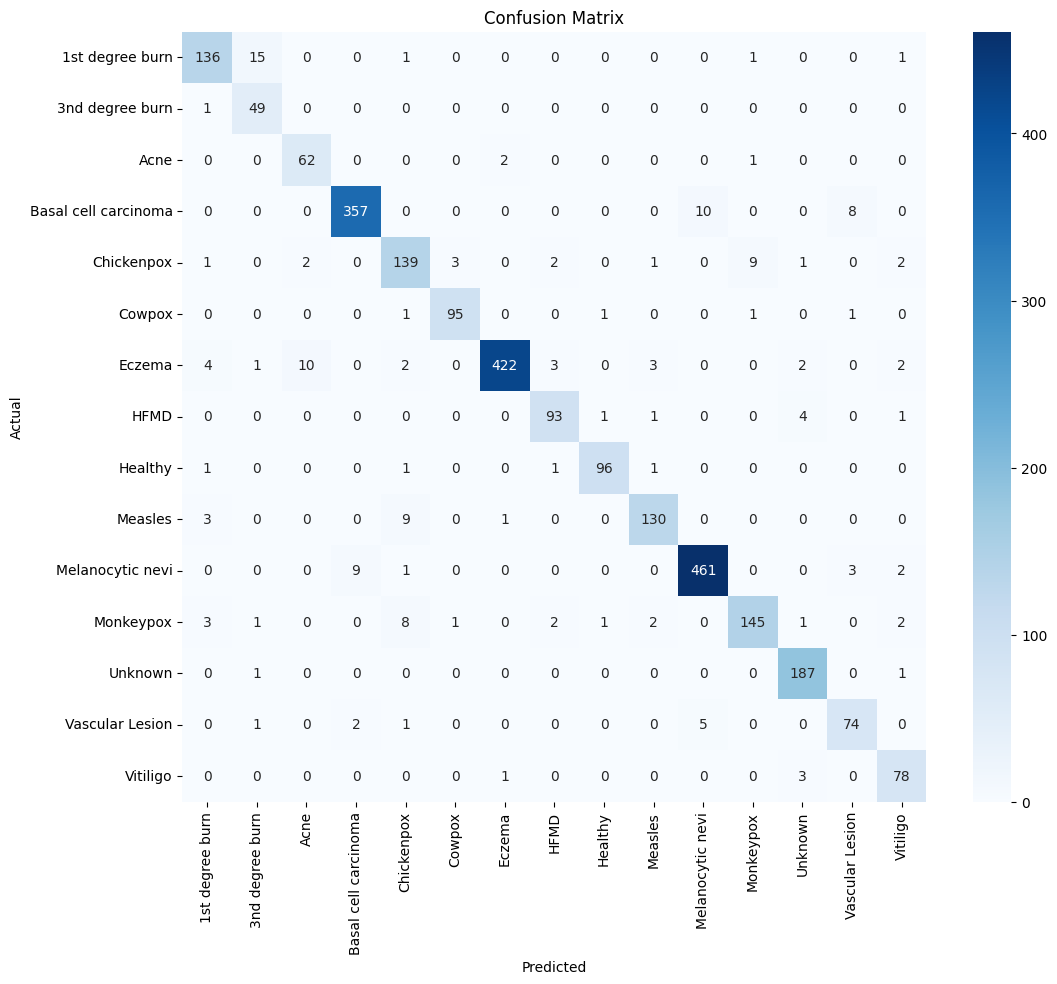

                      precision    recall  f1-score   support

     1st degree burn       0.91      0.88      0.90       154
     3nd degree burn       0.72      0.98      0.83        50
                Acne       0.84      0.95      0.89        65
Basal cell carcinoma       0.97      0.95      0.96       375
          Chickenpox       0.85      0.87      0.86       160
              Cowpox       0.96      0.96      0.96        99
              Eczema       0.99      0.94      0.96       449
                HFMD       0.92      0.93      0.93       100
             Healthy       0.97      0.96      0.96       100
             Measles       0.94      0.91      0.93       143
    Melanocytic nevi       0.97      0.97      0.97       476
           Monkeypox       0.92      0.87      0.90       166
             Unknown       0.94      0.99      0.97       189
     Vascular Lesion       0.86      0.89      0.88        83
            Vitiligo       0.88      0.95      0.91        82

      

In [16]:
test_loss, test_acc, test_auc = model.evaluate(test_generator)
print(f"Test AUC: {test_auc:.4f}, Test Accuracy: {test_acc:.4f}")

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = list(test_generator.class_indices.keys())

y_true = test_generator.classes
y_pred = model.predict(test_generator).argmax(axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

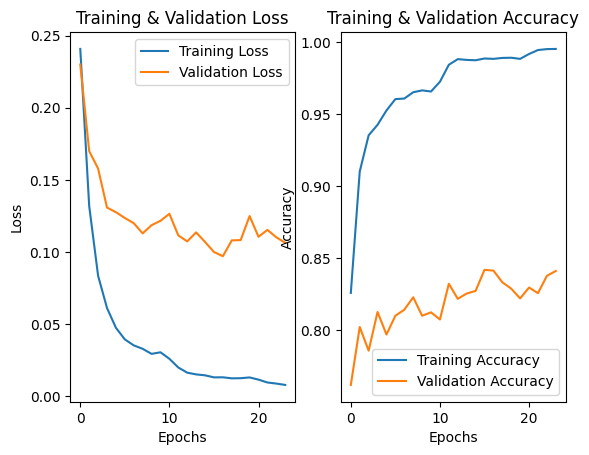

In [17]:
# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.show()

In [18]:
model.save("/kaggle/working/Final_Model.keras")
print("Done")

Done
